In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/washington-real-estate-sold-properties-data-2026/washington_ultimate.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/kanchana1990/washington-real-estate-sold-properties-data-2026/washington_ultimate.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12017 entries, 0 to 12016
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   zip                 12014 non-null  float64
 1   type                12017 non-null  object 
 2   year_built          11157 non-null  float64
 3   listPrice           10325 non-null  float64
 4   lastSoldPrice       12002 non-null  float64
 5   list_to_sold_ratio  10310 non-null  float64
 6   sqft                11145 non-null  float64
 7   price_per_sqft      11121 non-null  float64
 8   stories             10506 non-null  float64
 9   beds                11085 non-null  float64
 10  baths               11533 non-null  float64
 11  baths_full          10768 non-null  float64
 12  baths_full_calc     11004 non-null  float64
 13  garage              2363 non-null   float64
 14  sanitized_text      10298 non-null  object 
dtypes: float64(13), object(2)
memory usage: 1.4+ MB


In [4]:
df.isnull().sum()

zip                      3
type                     0
year_built             860
listPrice             1692
lastSoldPrice           15
list_to_sold_ratio    1707
sqft                   872
price_per_sqft         896
stories               1511
beds                   932
baths                  484
baths_full            1249
baths_full_calc       1013
garage                9654
sanitized_text        1719
dtype: int64

In [5]:
df.describe()

,zip,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage
count,12014.000000,11157.000000,1.032500e+04,1.200200e+04,10310.000000,11145.000000,11121.000000,10506.000000,11085.000000,11533.000000,10768.000000,11004.000000,2363.000000
mean,98470.878059,1985.959129,7.018486e+05,7.291245e+05,0.991343,2007.775684,367.886257,1.561965,3.262517,2.363565,1.748978,2.101509,2.194245
std,396.832853,32.268603,5.507031e+05,7.078002e+05,0.062016,1113.447253,189.541242,0.775282,1.112333,1.151564,0.838412,0.909202,0.925196
min,98001.000000,1875.000000,1.000000e+03,1.000000e+03,0.002800,120.000000,0.650000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,98122.000000,1967.000000,4.050620e+05,4.000288e+05,0.978300,1340.000000,251.390000,1.000000,3.000000,2.000000,1.000000,2.000000,2.000000
50%,98371.000000,1992.000000,5.699740e+05,5.680060e+05,1.000000,1810.000000,324.300000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000
75%,98665.000000,2013.000000,8.000810e+05,8.249120e+05,1.000400,2440.000000,440.660000,2.000000,4.000000,3.000000,2.000000,2.000000,3.000000
max,99403.000000,2026.000000,1.090007e+07,1.575121e+07,2.224900,29680.000000,1988.730000,31.000000,18.000000,20.000000,32.000000,32.000000,10.000000


**EDA**

In [6]:
df=df.drop(columns=["garage"])

In [7]:
df["year_built"].fillna(df["year_built"].median(), inplace=True)
df["sqft"].fillna(df["sqft"].median(), inplace=True)
df["beds"].fillna(df["beds"].median(), inplace=True)
df["baths"].fillna(df["baths"].median(), inplace=True)

/tmp/ipykernel_17/495190236.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["year_built"].fillna(df["year_built"].median(), inplace=True)
/tmp/ipykernel_17/495190236.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

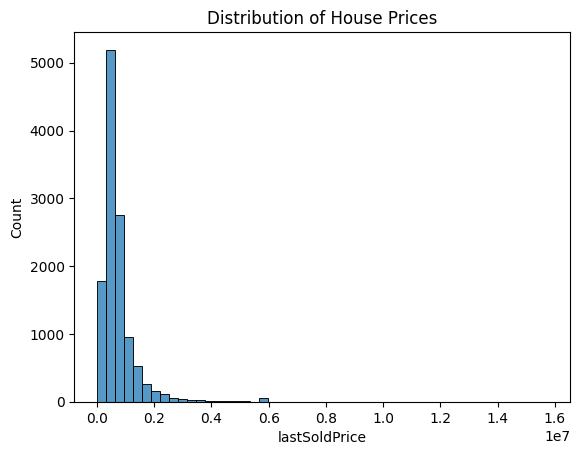

In [8]:
sns.histplot(df["lastSoldPrice"], bins=50)
plt.title("Distribution of House Prices")
plt.show()

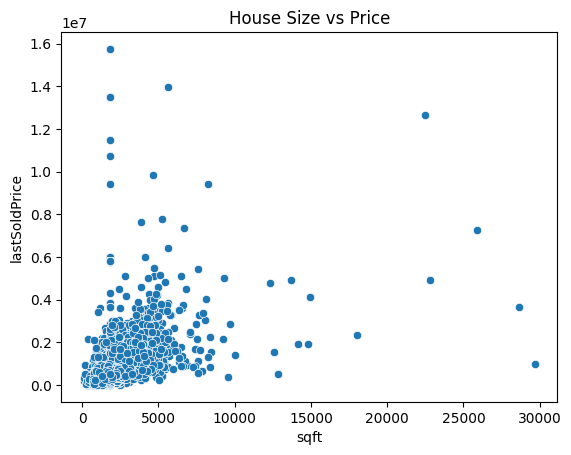

In [9]:
sns.scatterplot(x="sqft", y="lastSoldPrice", data=df)
plt.title("House Size vs Price")
plt.show()

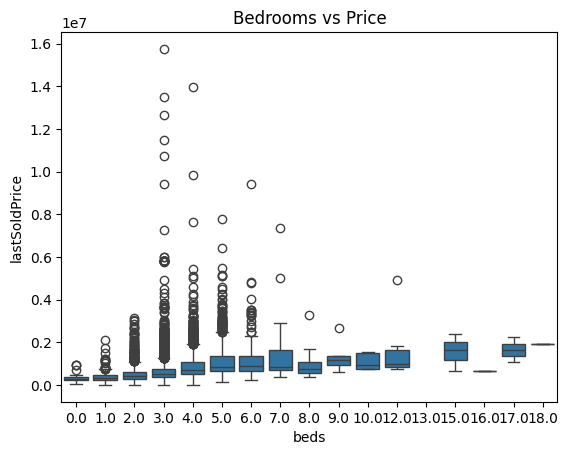

In [10]:
sns.boxplot(x="beds", y="lastSoldPrice", data=df)
plt.title("Bedrooms vs Price")
plt.show()

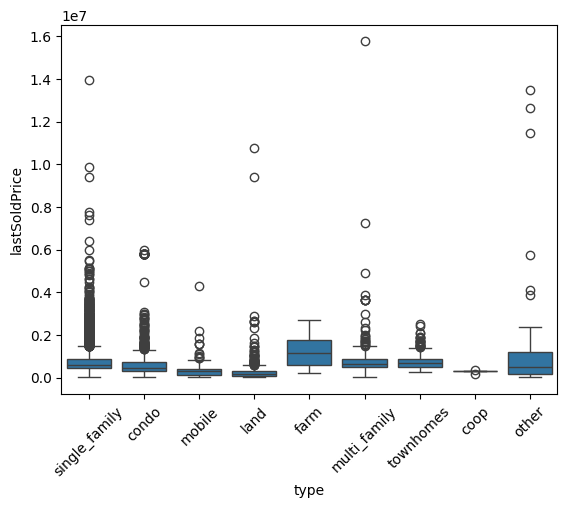

In [11]:
sns.boxplot(x="type", y="lastSoldPrice", data=df)
plt.xticks(rotation=45)
plt.show()

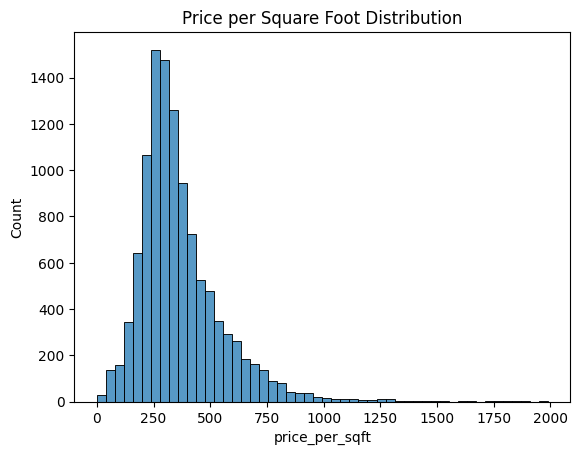

In [12]:
sns.histplot(df["price_per_sqft"], bins=50)
plt.title("Price per Square Foot Distribution")
plt.show()

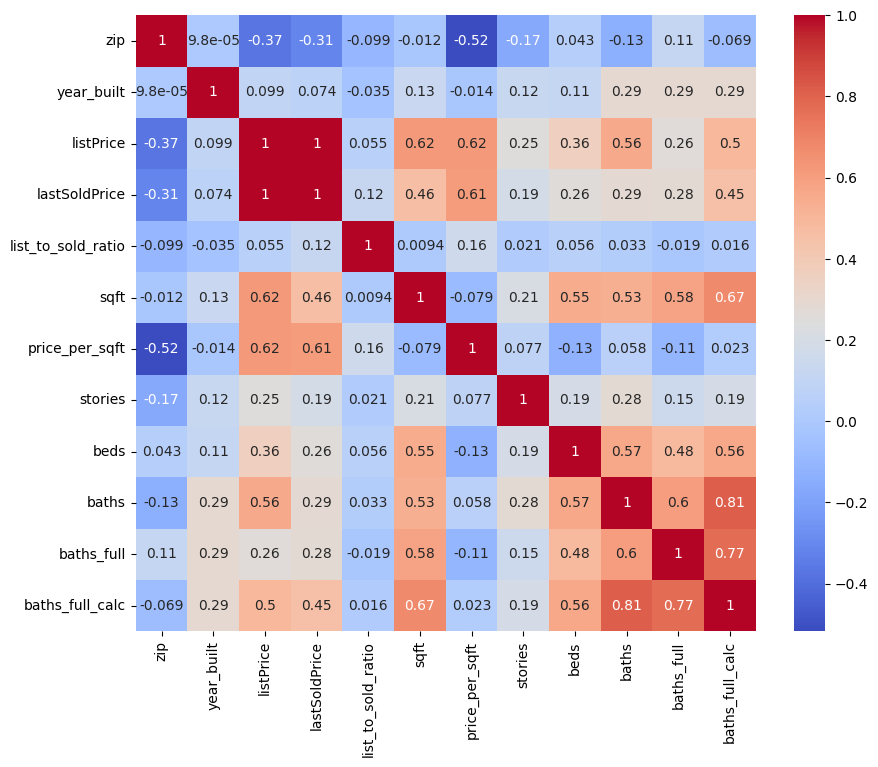

In [13]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

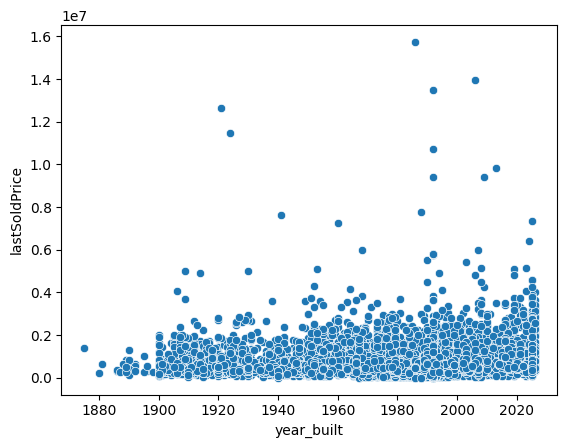

In [14]:
sns.scatterplot(x="year_built", y="lastSoldPrice", data=df)
plt.show()

**NLP**

In [15]:
from wordcloud import WordCloud

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

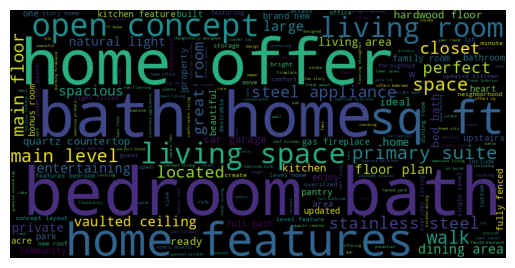

In [16]:
text=" ".join(df["sanitized_text"].dropna())
wc=WordCloud(width=800,height=400).generate(text)
plt.imshow(wc)
plt.axis("off")

In [17]:
df["house_age"]=2026-df["year_built"]

<Axes: xlabel='house_age', ylabel='lastSoldPrice'>

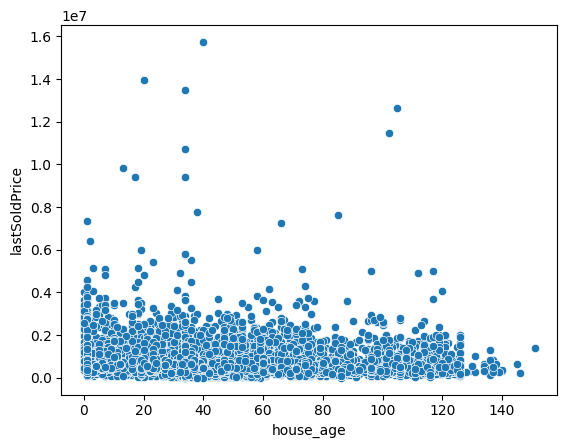

In [18]:
sns.scatterplot(x="house_age", y="lastSoldPrice", data=df)

## Summary of Findings

This analysis explored the dataset using several exploratory data analysis (EDA) techniques.  
Data visualization helped reveal important patterns and relationships within the dataset.

Key insights from the analysis include:

- The distribution of the main variables shows clear patterns across the dataset.
- Visualization techniques such as histograms, correlation plots, and word clouds helped highlight important trends.
- Some features show strong relationships which may be useful for further machine learning or predictive modeling.
- The word cloud visualization provided a quick overview of the most frequent terms appearing in the dataset.

Overall, the exploratory analysis provides a better understanding of the dataset and highlights potential directions for future analysis or modeling.